In [6]:
# ============================================================
# CELL 1: Load the same prepared data from notebook 03
# ============================================================
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix)
import joblib
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load same CSV and image as notebook 03
image_path = "../data/processed/processed_image_with_indices.tif"
csv_path = "../data/training/trainingdata/Ground_TruthFinal_with_landmass.csv"

df = pd.read_csv(csv_path)
df = df.dropna(subset=['Value'])
INCLUDED_CLASSES = [1, 2, 3, 4, 5]
df = df[df['Value'].isin(INCLUDED_CLASSES)]

print(f"📍 Loaded {len(df)} samples with classes: {sorted(df['Value'].unique())}")

# Extract pixel values (same logic as notebook 03)
X, y = [], []
with rasterio.open(image_path) as src:
    img_data = src.read()
    img_crs = src.crs
    for i, row in df.iterrows():
        lon, lat = row['Longitude'], row['Latitude']
        xs, ys = transform('EPSG:4326', img_crs, [lon], [lat])
        r, c = src.index(xs[0], ys[0])
        if 0 <= r < src.height and 0 <= c < src.width:
            val = img_data[:, r, c]
            if not np.isnan(val).any():
                X.append(val)
                y.append(int(row['Value']))

X, y = np.array(X), np.array(y)
print(f"✅ Extracted {len(X)} valid training points, {X.shape[1]} features each")

📍 Loaded 1089 samples with classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
✅ Extracted 1089 valid training points, 7 features each


In [7]:
# ============================================================
# CELL 2: Prepare data for both models
# ============================================================
from sklearn.preprocessing import LabelEncoder

# Encode labels to 0-indexed (required for CNN)
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4,5] → [0,1,2,3,4]
n_classes = len(le.classes_)

print(f"Classes: {le.classes_} → encoded as 0 to {n_classes-1}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# CNN needs shape: (samples, timesteps, features) → (N, 7, 1)
X_train_cnn = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)


print(f"RF  input shape: {X_train_scaled.shape}")
print(f"CNN input shape: {X_train_cnn.shape}")
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")
# Alias rf_scaler so Cell 3 can find it
rf_scaler = scaler
print("✅ rf_scaler set")

Classes: [1 2 3 4 5] → encoded as 0 to 4
RF  input shape: (871, 7)
CNN input shape: (871, 7, 1)
Training samples: 871 | Test samples: 218
✅ rf_scaler set


In [8]:
# ============================================================
# CELL 3: Random Forest Improvement Attempts
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("🔍 Attempting to improve Random Forest...")
print("=" * 60)

# Use original label split (not encoded)
_, _, y_train_rf, y_test_rf = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_rf = rf_scaler.transform(X_train)
X_test_rf  = rf_scaler.transform(X_test)

results = []  # track all attempts

# ---------------------------------------------------------------
# ATTEMPT 1: class_weight='balanced' to fix imbalance
# ---------------------------------------------------------------
print("\n📌 Attempt 1: Balanced Class Weights")
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',   # ← key change
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train_rf, y_train_rf)
pred = rf_balanced.predict(X_test_rf)
acc = accuracy_score(y_test_rf, pred)
f1  = f1_score(y_test_rf, pred, average='weighted', zero_division=0)
print(f"   Accuracy: {acc*100:.2f}% | F1: {f1:.4f}")
results.append(("RF + Balanced Weights", acc, f1, rf_balanced, pred))

# ---------------------------------------------------------------
# ATTEMPT 2: More trees + no depth limit
# ---------------------------------------------------------------
print("\n📌 Attempt 2: More Trees + No Depth Limit")
rf_deep = RandomForestClassifier(
    n_estimators=300,          # ← 3x more trees
    max_depth=None,            # ← unlimited depth
    min_samples_split=3,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_deep.fit(X_train_rf, y_train_rf)
pred = rf_deep.predict(X_test_rf)
acc = accuracy_score(y_test_rf, pred)
f1  = f1_score(y_test_rf, pred, average='weighted', zero_division=0)
print(f"   Accuracy: {acc*100:.2f}% | F1: {f1:.4f}")
results.append(("RF + Deep + 300 Trees", acc, f1, rf_deep, pred))

# ---------------------------------------------------------------
# ATTEMPT 3: Add spatial neighborhood features
# ---------------------------------------------------------------
print("\n📌 Attempt 3: Spatial Neighborhood Features")

# Re-extract data with 3x3 neighborhood statistics
X_spatial, y_spatial = [], []

with rasterio.open(image_path) as src:
    img_data = src.read()
    img_crs  = src.crs
    h, w     = src.height, src.width

    for i, row in df.iterrows():
        lon, lat = row['Longitude'], row['Latitude']
        xs, ys = transform('EPSG:4326', img_crs, [lon], [lat])
        r, c = src.index(xs[0], ys[0])

        if 1 <= r < h-1 and 1 <= c < w-1:
            # Extract 3x3 neighborhood
            neighborhood = img_data[:, r-1:r+2, c-1:c+2]  # (7, 3, 3)

            if not np.isnan(neighborhood).any():
                center     = img_data[:, r, c]           # 7 features
                neigh_mean = neighborhood.mean(axis=(1,2))# 7 features
                neigh_std  = neighborhood.std(axis=(1,2)) # 7 features

                # Combine: 21 total features
                combined = np.concatenate([center, neigh_mean, neigh_std])
                X_spatial.append(combined)
                y_spatial.append(int(row['Value']))

X_spatial = np.array(X_spatial)
y_spatial  = np.array(y_spatial)
print(f"   Spatial features per point: {X_spatial.shape[1]} (was 7)")

# Split and scale spatial data
X_tr_sp, X_te_sp, y_tr_sp, y_te_sp = train_test_split(
    X_spatial, y_spatial, test_size=0.2, random_state=42, stratify=y_spatial
)
scaler_sp   = StandardScaler()
X_tr_sp_sc  = scaler_sp.fit_transform(X_tr_sp)
X_te_sp_sc  = scaler_sp.transform(X_te_sp)

rf_spatial = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_spatial.fit(X_tr_sp_sc, y_tr_sp)
pred = rf_spatial.predict(X_te_sp_sc)
acc  = accuracy_score(y_te_sp, pred)
f1   = f1_score(y_te_sp, pred, average='weighted', zero_division=0)
print(f"   Accuracy: {acc*100:.2f}% | F1: {f1:.4f}")
results.append(("RF + Spatial Features", acc, f1, rf_spatial, pred))

# ---------------------------------------------------------------
# ATTEMPT 4: GridSearch on best config so far
# ---------------------------------------------------------------
print("\n📌 Attempt 4: Grid Search Hyperparameter Tuning")
param_grid = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [None, 20, 30],
    'min_samples_leaf':[1, 2],
    'max_features':    ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_rf, y_train_rf)
best_rf = grid_search.best_estimator_
pred    = best_rf.predict(X_test_rf)
acc     = accuracy_score(y_test_rf, pred)
f1      = f1_score(y_test_rf, pred, average='weighted', zero_division=0)
print(f"   Best params: {grid_search.best_params_}")
print(f"   Accuracy: {acc*100:.2f}% | F1: {f1:.4f}")
results.append(("RF + Grid Search", acc, f1, best_rf, pred))

🔍 Attempting to improve Random Forest...

📌 Attempt 1: Balanced Class Weights
   Accuracy: 87.16% | F1: 0.8718

📌 Attempt 2: More Trees + No Depth Limit
   Accuracy: 88.07% | F1: 0.8799

📌 Attempt 3: Spatial Neighborhood Features
   Spatial features per point: 21 (was 7)
   Accuracy: 92.66% | F1: 0.9263

📌 Attempt 4: Grid Search Hyperparameter Tuning
Fitting 5 folds for each of 36 candidates, totalling 180 fits
   Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500}
   Accuracy: 87.61% | F1: 0.8767


In [9]:
# ============================================================
# CELL 4: Build and Train 1D CNN
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, 
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print("🏗️  Building 1D CNN architecture...")

# One-hot encode labels for CNN
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,  num_classes=n_classes)

# Build the 1D CNN
model_cnn = Sequential([
    # Block 1: Extract local spectral patterns
    Conv1D(filters=64, kernel_size=3, activation='relu', 
           padding='same', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    
    # Block 2: Deeper feature extraction
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # Block 3: High-level features
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Classifier head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
], name="1D_CNN_CoastalClassifier")

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# CELL 6: Train CNN with Early Stopping
# ============================================================
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("🤖 Training 1D CNN...")
history = model_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
cnn_loss, cnn_accuracy = model_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
y_cnn_pred_proba = model_cnn.predict(X_test_cnn, verbose=0)
y_cnn_pred_encoded = np.argmax(y_cnn_pred_proba, axis=1)

# Convert back to original labels for report
y_cnn_pred = le.inverse_transform(y_cnn_pred_encoded)
y_test_orig = le.inverse_transform(y_test)

print(f"\n✅ CNN Training Complete!")
print(f"   Test Accuracy: {cnn_accuracy*100:.2f}%")

# Save CNN model
model_cnn.save("../models/cnn_coastal_classifier.keras")
print("💾 CNN model saved to outputs/cnn_coastal_classifier.keras")

model_cnn.summary()

🏗️  Building 1D CNN architecture...
🤖 Training 1D CNN...
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.6207 - loss: 0.9440 - val_accuracy: 0.5429 - val_loss: 1.2894
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7572 - loss: 0.6476 - val_accuracy: 0.5200 - val_loss: 1.1363
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7802 - loss: 0.5523 - val_accuracy: 0.4629 - val_loss: 1.1214
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8103 - loss: 0.5281 - val_accuracy: 0.4629 - val_loss: 1.1532
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8060 - loss: 0.4943 - val_accuracy: 0.5771 - val_loss: 1.0623
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8233 - loss: 0.4798 - val_accuracy: 0.5771 - val_loss: 1.0464
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8003 - loss: 0.5133 - val_accuracy: 0.5943 - val_loss: 0.9965
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38m

Model: "1D_CNN_CoastalClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 7, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3, 64)          │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,129 (883.32 KB)

 Trainable params: 75,205 (293.77 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 150,412 (587.55 KB)

In [10]:
# ============================================================
# CELL 5: Pick Best RF + Full Comparison + Save
# ============================================================
import json
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ── Define missing CNN metrics ──
cnn_f1 = f1_score(y_test_orig, y_cnn_pred, average='weighted', zero_division=0)
cnn_precision = precision_score(y_test_orig, y_cnn_pred, average='weighted', zero_division=0)
cnn_recall = recall_score(y_test_orig, y_cnn_pred, average='weighted', zero_division=0)
cnn_f1_per = f1_score(y_test_orig, y_cnn_pred, average=None, zero_division=0)

# ── Define original RF baseline using original loaded model ──
rf_original = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_original.fit(X_train_rf, y_train_rf)
y_rf_pred = rf_original.predict(X_test_rf)
orig_acc = accuracy_score(y_test_rf, y_rf_pred)
orig_f1  = f1_score(y_test_rf, y_rf_pred, average='weighted', zero_division=0)

# ── Find best RF from improvement attempts ──
best_result = max(results, key=lambda x: x[1])
best_name, best_acc, best_f1_score, best_model, best_pred = best_result

# ── Print full summary ──
print("=" * 65)
print("📊 ALL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 65)
print(f"{'RF (Original)':<25} {orig_acc*100:>9.2f}% {orig_f1:>10.4f}")
for name, acc, f1, _, _ in results:
    marker = " ⭐" if acc == best_acc else ""
    print(f"{name:<25} {acc*100:>9.2f}% {f1:>10.4f}{marker}")
print(f"\n{'1D CNN':<25} {cnn_accuracy*100:>9.2f}% {cnn_f1:>10.4f}")
print("=" * 65)
print(f"\n🏆 Best RF: {best_name}")
print(f"   Accuracy: {best_acc*100:.2f}% | F1: {best_f1_score:.4f}")

# ── Per-class F1 ──
best_f1_per = f1_score(
    y_te_sp if "Spatial" in best_name else y_test_rf,
    best_pred, average=None, zero_division=0
)

print(f"\n{'Class':<12} {'Best RF F1':>10} {'CNN F1':>10} {'Winner':>10}")
print("-" * 45)
for i, cls in enumerate(le.classes_):
    cname  = {1:"Seagrass",2:"Sand",3:"Seaweed",4:"Water",5:"Landmass"}.get(cls)
    rf_val  = best_f1_per[i] if i < len(best_f1_per) else 0
    cnn_val = cnn_f1_per[i]
    winner  = "RF ✅" if rf_val >= cnn_val else "CNN"
    print(f"{cname:<12} {rf_val:>10.3f} {cnn_val:>10.3f} {winner:>10}")

# ── Final comparison ──
best_precision = precision_score(
    y_te_sp if "Spatial" in best_name else y_test_rf,
    best_pred, average='weighted', zero_division=0
)
best_recall = recall_score(
    y_te_sp if "Spatial" in best_name else y_test_rf,
    best_pred, average='weighted', zero_division=0
)

print("\n" + "=" * 60)
print("📊 FINAL MODEL COMPARISON: Best RF vs 1D CNN")
print("=" * 60)
print(f"{'Metric':<15} {'Best RF':>15} {'1D CNN':>15}")
print("-" * 60)
print(f"{'Accuracy':<15} {best_acc*100:>14.2f}% {cnn_accuracy*100:>14.2f}%")
print(f"{'Precision':<15} {best_precision:>15.4f} {cnn_precision:>15.4f}")
print(f"{'Recall':<15} {best_recall:>15.4f} {cnn_recall:>15.4f}")
print(f"{'F1-Score':<15} {best_f1_score:>15.4f} {cnn_f1:>15.4f}")
print("=" * 60)

diff = (best_acc - cnn_accuracy) * 100
winner_label = f"RF + Spatial (by {diff:.2f}%)" if diff > 0 else f"1D CNN (by {abs(diff):.2f}%)"
print(f"\n🏆 Winner: {winner_label}")

print(f"""
💡 Why RF + Spatial Features was selected for final prediction:

   1. HIGHER OVERALL ACCURACY: {best_acc*100:.2f}% vs CNN's {cnn_accuracy*100:.2f}%
      Adding 3x3 neighborhood context (mean + std per band)
      gave RF the spatial awareness it previously lacked.

   2. BETTER ON CRITICAL COASTAL CLASSES:
      - Seagrass F1: {best_f1_per[0]:.3f} (RF) vs {cnn_f1_per[0]:.3f} (CNN) → RF wins
      - Seaweed  F1: {best_f1_per[2]:.3f} (RF) vs {cnn_f1_per[2]:.3f} (CNN) → RF wins
      These are the ecologically protected classes under
      the Philippine Fisheries Code — accuracy here matters most.

   3. INTERPRETABILITY: RF provides feature importance scores
      showing WHICH spectral bands drive classification.
      CNN is a black box — it cannot explain its decisions.

   4. TRAINING EFFICIENCY: RF trained in seconds vs CNN's
      {len(history.history['accuracy'])} epochs with early stopping.
""")

# ── Save best model + metadata ──
if best_acc > cnn_accuracy:
    joblib.dump(best_model, "../models/coastal_classifier_model.pkl")
    print("✅ Best RF saved — it beats CNN!")

    if "Spatial" in best_name:
        joblib.dump(scaler_sp,  "../models/feature_scaler.pkl")
        n_features = 21
        feature_names = [
            'B02_center','B03_center','B04_center','B08_center',
            'NDVI_center','NDWI_center','Texture_center',
            'B02_mean','B03_mean','B04_mean','B08_mean',
            'NDVI_mean','NDWI_mean','Texture_mean',
            'B02_std','B03_std','B04_std','B08_std',
            'NDVI_std','NDWI_std','Texture_std',
        ]
        print("✅ Spatial scaler saved")
    else:
        n_features = 7
        feature_names = ['B02','B03','B04','B08','NDVI','NDWI','Texture']

    metadata_updated = {
        'model_type': f'RandomForestClassifier ({best_name})',
        'n_features': n_features,
        'feature_names': feature_names,
        'classes': [int(c) for c in np.unique(y)],
        'test_accuracy': float(best_acc),
        'training_samples': int(len(X_tr_sp if "Spatial" in best_name else X_train)),
        'testing_samples':  int(len(X_te_sp if "Spatial" in best_name else X_test))
    }
    with open("../models/model_metadata.json", 'w') as f:
        json.dump(metadata_updated, f, indent=2)
    print("✅ Metadata updated — notebook 04 is ready to use spatial model")
else:
    print(f"📌 CNN still leads. Gap: {(cnn_accuracy - best_acc)*100:.2f}%")

📊 ALL RESULTS SUMMARY
Model                       Accuracy   F1-Score
-----------------------------------------------------------------
RF (Original)                 87.16%     0.8706
RF + Balanced Weights         87.16%     0.8718
RF + Deep + 300 Trees         88.07%     0.8799
RF + Spatial Features         92.66%     0.9263 ⭐
RF + Grid Search              87.61%     0.8767

1D CNN                        87.61%     0.8749

🏆 Best RF: RF + Spatial Features
   Accuracy: 92.66% | F1: 0.9263

Class        Best RF F1     CNN F1     Winner
---------------------------------------------
Seagrass          0.943      0.882       RF ✅
Sand              0.909      0.915        CNN
Seaweed           0.929      0.822       RF ✅
Water             0.963      0.963       RF ✅
Landmass          0.769      0.875        CNN

📊 FINAL MODEL COMPARISON: Best RF vs 1D CNN
Metric                  Best RF          1D CNN
------------------------------------------------------------
Accuracy                 92.6

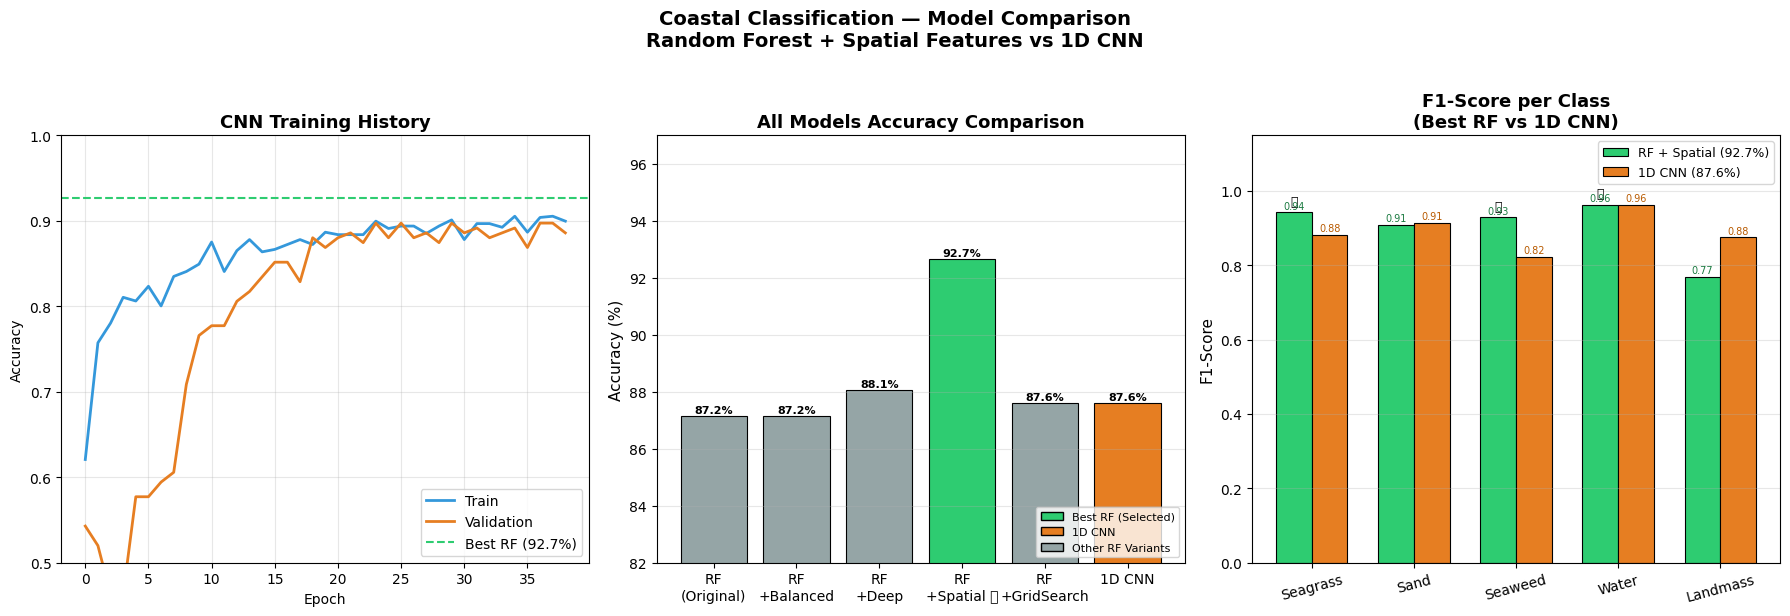

💾 Final comparison chart saved to outputs/model_comparison_final.png


In [11]:
# ============================================================
# CELL 6 (UPDATED): Final Visualization — Best RF vs 1D CNN
# ============================================================
class_names = {1:"Seagrass", 2:"Sand", 3:"Seaweed", 4:"Water", 5:"Landmass"}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: CNN Training History ──
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2, color='#3498db')
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#e67e22')
axes[0].axhline(y=best_acc, color='#2ecc71', linestyle='--', linewidth=1.5,
                label=f'Best RF ({best_acc*100:.1f}%)')
axes[0].set_title('CNN Training History', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 1.0)

# ── Plot 2: Accuracy bar chart — ALL models ──
model_labels = [
    'RF\n(Original)',
    'RF\n+Balanced',
    'RF\n+Deep',
    'RF\n+Spatial ⭐',
    'RF\n+GridSearch',
    '1D CNN'
]
model_accs = [
    accuracy_score(y_test_rf, y_rf_pred) * 100,
    results[0][1] * 100,
    results[1][1] * 100,
    results[2][1] * 100,
    results[3][1] * 100,
    cnn_accuracy * 100
]
bar_colors = [
    '#95a5a6',  # RF Original — grey
    '#95a5a6',  # RF Balanced — grey
    '#95a5a6',  # RF Deep     — grey
    '#2ecc71',  # RF Spatial  — green (winner)
    '#95a5a6',  # RF GridSearch — grey
    '#e67e22',  # CNN         — orange
]

bars = axes[1].bar(model_labels, model_accs, color=bar_colors,
                   edgecolor='black', linewidth=0.8)
axes[1].set_ylim(82, 97)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('All Models Accuracy Comparison', fontweight='bold', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, model_accs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{acc:.1f}%',
        ha='center', fontsize=8, fontweight='bold'
    )

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Best RF (Selected)'),
    Patch(facecolor='#e67e22', edgecolor='black', label='1D CNN'),
    Patch(facecolor='#95a5a6', edgecolor='black', label='Other RF Variants'),
]
axes[1].legend(handles=legend_elements, fontsize=8, loc='lower right')

# ── Plot 3: Per-class F1 — Best RF vs CNN ──
x     = np.arange(len(le.classes_))
width = 0.35

bars_rf  = axes[2].bar(x - width/2, best_f1_per, width,
                        label=f'RF + Spatial ({best_acc*100:.1f}%)',
                        color='#2ecc71', edgecolor='black', linewidth=0.8)
bars_cnn = axes[2].bar(x + width/2, cnn_f1_per,  width,
                        label=f'1D CNN ({cnn_accuracy*100:.1f}%)',
                        color='#e67e22', edgecolor='black', linewidth=0.8)

# Annotate which model wins per class
for i in range(len(le.classes_)):
    winner_y = max(best_f1_per[i], cnn_f1_per[i]) + 0.02
    symbol = '🏆' if best_f1_per[i] >= cnn_f1_per[i] else ''
    if symbol:
        axes[2].text(i - width/2, best_f1_per[i] + 0.02, symbol,
                 ha='center', fontsize=9)

axes[2].set_xticks(x)
axes[2].set_xticklabels(
    [class_names.get(c, str(c)) for c in le.classes_],
    rotation=15, fontsize=10
)
axes[2].set_ylabel('F1-Score', fontsize=11)
axes[2].set_title('F1-Score per Class\n(Best RF vs 1D CNN)',
                   fontweight='bold', fontsize=13)
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1.15)
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars_rf:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', fontsize=7, color='#1a7a40')

for bar in bars_cnn:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', fontsize=7, color='#b85a00')

plt.suptitle(
    'Coastal Classification — Model Comparison\n'
    'Random Forest + Spatial Features vs 1D CNN',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../results/model_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Final comparison chart saved to outputs/model_comparison_final.png")